In [148]:
import os
import json
import glob
import matplotlib.pyplot as plt
import time
import sys
from tqdm import tqdm

import numpy as np
from qiskit.quantum_info import SparsePauliOp
from qaoa_training_pipeline.utils.graph_utils import load_graph, solve_max_cut, graph_to_operator
from qopt_best_practices.cost_function.cost_utils import counts_to_maxcut_cost
from qaoa_parameter_setting.utils.analysis import quantile, mean_obj, standard_error_mean

# Plotting training and hardware data

In [149]:
def load_json(partial_name, directory="."):

    pattern = os.path.join(directory, f"*{partial_name}*.json")
    matches = glob.glob(pattern)

    if not matches:
        raise FileNotFoundError(f"No JSON files found matching: {partial_name}")

    with open(matches[0], "r") as f:
        data = json.load(f)
    return data

In [150]:
def energy_data(folder, short_name, depth, max_cuts, min_cuts, top_pc):
    
    all_summaries = []
    matches = []
    all_methods = []
    file_data   = []
    
    for n in range(num_files):
        prefix = f"data/hardware/{folder}/00{n}{short_name}_{depth}"
        found = glob.glob(prefix + "*.json")
        matches.extend(found)

    bar = tqdm(total=len(matches), desc=f"p = {depth}")
    
    for fname in matches:
        try:
            with open(fname, "r") as fin:
                res_summary = json.load(fin)
    
            basename = os.path.basename(fname)
            prefix_digits = ''.join([c for c in basename if c.isdigit()][:3])
            n = int(prefix_digits)
    
            graph = load_graph(f"instances/{folder}/00{n}{instance}")
            denom = max_cuts[n] - min_cuts[n]
            denom = denom if denom != 0 else np.nan
    
            methods = set()
            energies = {}
    
            for res in res_summary:
                meta = res.get("metadata")
                if not meta:
                    continue
    
                counts = res.get("counts")
                if counts is None:
                    continue
    
                # Compute cost + shots
                mc_cost = counts_to_maxcut_cost(graph, counts)
                shots   = sum(counts.values())
                mc_cost_2= {k: int(v * shots) for k, v in  mc_cost.items()}
                sk=sorted(mc_cost_2.keys(), reverse=True)
                y_vals = np.cumsum([mc_cost_2[x] for x in sk])
                threshold=int(shots*top_pc/100)
                idx = np.searchsorted(y_vals, threshold)
                top_mc_cost = {k: mc_cost_2[k] for k in sk[:idx+1]}
                top_mc_cost[sk[idx]]-= y_vals[idx]-threshold
                top_mc_cost= {k: top_mc_cost[k]/threshold for k in sk[:idx+1]}

                # Normalized mean + sem
                mean_norm = 100 * (mean_obj(top_mc_cost) - min_cuts[n]) / denom
                sem_norm  = 100 * standard_error_mean(top_mc_cost, threshold) / denom
    
                # Metadata extraction
                circ_meta = meta.get("circuit_metadata", {})
                label = circ_meta.get("method")
                val   = circ_meta.get("eval_energy")
    
                methods.add(label)
                energies.setdefault(label, []).append([val, mean_norm, sem_norm])
    
            all_methods.append(methods)
            file_data.append(energies)
    
        except FileNotFoundError:
            print(f"Missing file: {fname}")

       # print(n)

        bar.update(1)
        
    bar.close()
    
    # Find shared labels
    shared_labels = set.intersection(*all_methods)
    # print("Shared labels:", shared_labels)
    
    # Collect energies per label 
    energy_dict = {label: [] for label in shared_labels}
    for energies in file_data:
        for label in shared_labels:
            if label in energies:
                energy_dict[label].append(energies[label])
                
    return shared_labels, energy_dict

In [151]:
prefix_map = {
    "F": [0, "Fourier", "#EE6677"],
    "FA": [1, "Fixed angles", "#4477AA"],
    "I": [2, "Interp.", "#228833"],
    "LR": [3, "Linear ramp", "#CCBB44"],
    "PT": [4, "Parameter transfer", "#BBBBBB"],
    "RTS": [5, "Recursive TS", "#66CCEE"],
    "TQA": [6, "TQA", "#AA3377"],
}

evaluator_map = {
    "MPS": [0, "MPS (Quimb)", "P"],
    "MPSAer": [1, "MPS (Aer)", "^"],
    "PP": [2, "PP", "s"],
    "SV": [3, "SV", "o"],
}
def adjust_method(abbr, prefix_map):
    parts = abbr.split('_')
    s = "_".join(parts).lower()
    if ("aaa" not in s and "lr" not in s) or ("lr" in s and "angle" in s):
        expanded= rf"{prefix_map[parts[0]][1]}$^{{\star}}$"
    else:
        expanded= f"{prefix_map[parts[0]][1]}"
    return expanded

def adjust_eval(eval_label):
    if "MPSAer" in eval_label:
        return "MPS (Aer)"
    elif "MPS" in eval_label:
        return "MPS (Quimb)"
    else:
        return eval_label

In [152]:
depths = [5, 10] # depth value
num_files = 10   # number of files per depth
pc = 5           # The top percent of shots to be averaged

# instance = "_30nodes_random3regular.json"
# short_name = "N30R3R"
# folder = "random_regular"
instance = "_7_3_heavyhex_144nodes_weighted.json"
short_name = "N144HH73"
folder = "heavy_hex"
# instance = "_40nodes_erdosrenyi20percent.json"
# short_name = "N40ER20"
# folder = "erdos_renyi"
# instance = "_100nodes_2swap_layers.json"
# short_name = "N100L2S2"
# folder = "line_to_full"


In [153]:
result_repo=f"../QAOA-Parameter-Setting-personal/data/training/{folder}"
max_cuts=[]
min_cuts=[]
ar_diffs=[]
bar = tqdm(total=num_files, desc="Computing MAXCUT values")

for n in range(num_files):
    data = load_json(f"00{n}{short_name}_MC", directory=result_repo)
    cost_op = SparsePauliOp.from_list(data["cost_operator"])
    max_cut, min_cut, ar = solve_max_cut(cost_op,  data["1"]["energy"])
    ar_diff= ar*(max_cut-min_cut)- data["1"]["energy"]
    max_cuts.append(max_cut)
    min_cuts.append(min_cut)
    ar_diffs.append(ar_diff)
    bar.update(1)
    
bar.close()

Computing MAXCUT values: 100%|██████████| 10/10 [01:06<00:00,  6.60s/it]


In [154]:
shared_labels={}
energy_dict={}
for depth in depths:
    labels, energies=energy_data(folder, short_name, depth, max_cuts, min_cuts, pc)
    shared_labels[depth]=labels
    energy_dict[depth]=energies

p = 10: 100%|██████████| 10/10 [01:28<00:00,  8.85s/it]


In [155]:
for k, vals in shared_labels.items():
    shared_labels[k] = {
        x for x in vals
        if not (("LR" in x and "angle" not in x) or ("no_opt" in x))
    }
shared_labels

{5: {'FA_MPSAer_opt_5',
  'FA_MPS_opt_5',
  'FA_PP_opt_5',
  'F_MPSAer_10',
  'F_MPS_10',
  'F_PP_10',
  'I_MPSAer_10',
  'I_MPS_10',
  'I_PP_10',
  'LR_MPSAer_angleOpt_5',
  'LR_MPS_angleOpt_5',
  'LR_PP_angleOpt_5',
  'PT_PP_AAA_5',
  'RTS_MPS_10',
  'RTS_PP_10',
  'TQA_MPSAer_opt_5',
  'TQA_MPS_opt_5',
  'TQA_PP_opt_5'},
 10: {'FA_MPSAer_opt_10',
  'FA_MPS_opt_10',
  'FA_PP_opt_10',
  'F_MPSAer_10',
  'F_MPS_10',
  'F_PP_10',
  'I_MPSAer_10',
  'I_MPS_10',
  'I_PP_10',
  'LR_MPSAer_angleOpt_10',
  'LR_MPS_angleOpt_10',
  'LR_PP_angleOpt_10',
  'PT_PP_AAA_10',
  'RTS_MPS_10',
  'RTS_PP_10',
  'TQA_MPSAer_opt_10',
  'TQA_MPS_opt_10',
  'TQA_PP_opt_10'}}

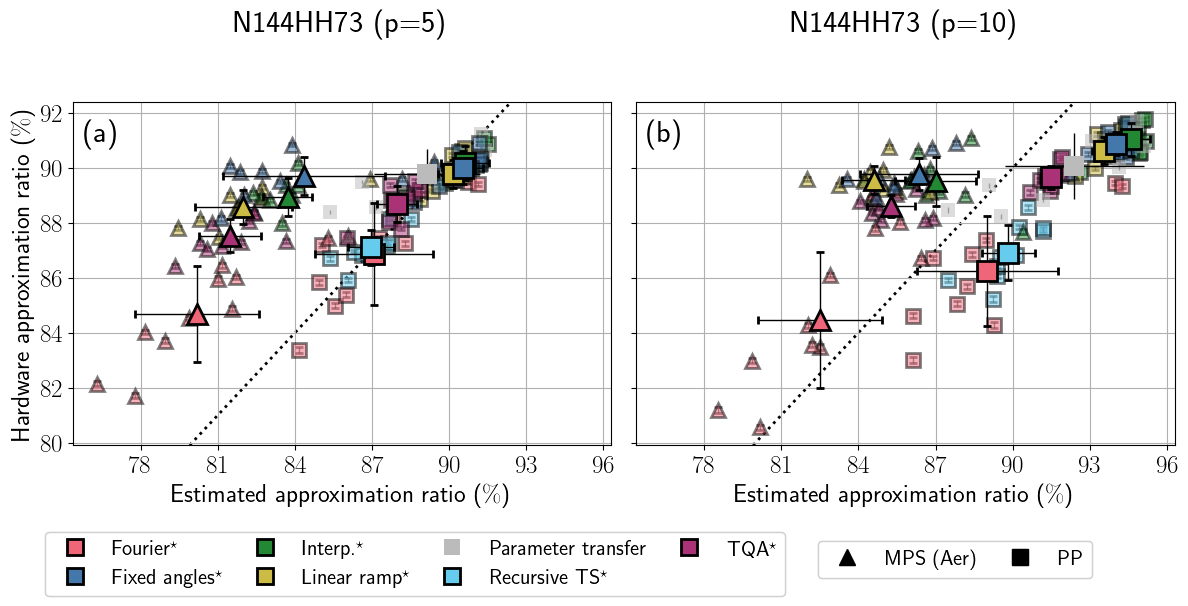

In [156]:
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

plt.rcParams["text.usetex"] = True
plt.rcParams["legend.columnspacing"] = 1

eval_list=["MPSAer", "PP"]

opts = {"mec": "k" , "ecolor": "k", "capsize": 3, "elinewidth": 1}

fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)

if len(depths) == 1:
    axs = [axs]

shared_labels_d = {}

xmins, xmaxs, ymins, ymaxs = [], [], [], []

for ax, depth in zip(axs, depths):

    shared_labels_d[depth] = {
        x for x in shared_labels[depth]
        if any(k in x.split('_') for k in eval_list)
    }

    for label in shared_labels_d[depth]:
        parts = label.split('_')
        marker = evaluator_map[parts[1]][2]
        color = prefix_map[parts[0]][2]
        arr = np.array(energy_dict[depth][label])
        arr0 = (arr[:, 0, 0] + np.array(ar_diffs).T) / (np.array(max_cuts).T - np.array(min_cuts).T)

        if "PT" in parts[0]:
            mew = 0
        else:
            mew = 2

        xvals = 100 * arr0.flatten()
        yvals = arr[:, 0, 1]
        xerr = np.std(xvals)
        yerr = np.std(yvals)

        ax.errorbar(
            xvals, yvals, yerr=arr[:, 0, 2],
            color=color,
            marker=marker,
            linestyle="none",
            alpha=0.5, ms=10,
            markeredgewidth=mew,
            **opts
        )

        h = ax.errorbar(
            np.average(xvals), np.average(yvals),
            xerr=xerr, yerr=yerr,
            color=color,
            marker=marker,
            linestyle="none",
            zorder=10, ms=15,
            markeredgewidth=mew,
            **opts
        )

    ax.grid(True)
    ax.set_xlabel("Estimated approximation ratio ($\%$)", fontsize=18)
    ax.set_title(f"{short_name} (p={depth})", fontsize=22, pad=50)
    ax.tick_params(axis="both", labelsize=18)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

    ax.relim()
    ax.autoscale_view()

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    xmins.append(xmin)
    xmaxs.append(xmax)
    ymins.append(ymin)
    ymaxs.append(ymax)

axs[0].set_ylabel("Hardware approximation ratio ($\%$)", fontsize=18)

shared_xmin = min(xmins)
shared_xmax = max(xmaxs)
shared_ymin = min(ymins)
shared_ymax = max(ymaxs)

for ax in axs:
    ax.set_xlim(shared_xmin, shared_xmax)
    ax.set_ylim(shared_ymin, shared_ymax)

    low = max(shared_xmin, shared_ymin)
    high = min(shared_xmax, shared_ymax)

    if low < high:
        ax.plot([low, high], [low, high], "k:", linewidth=2, zorder=0)

# Sorting legends
color_list = {}
marker_list = {}

for depth in depths:
    for label in shared_labels_d[depth]:

        parts = label.split('_')

        prefix = parts[0]
        backend = parts[1]

        eval_struct = evaluator_map[backend]
        color_struct = prefix_map[prefix]

        if "PT" in prefix:
            mew = 0
        else:
            mew = 2
        
        if color_struct[0] not in color_list:
            color_list[color_struct[0]]=[adjust_method(label, prefix_map), prefix_map[prefix][2], mew]

        if eval_struct[0] not in marker_list:
            marker_list[eval_struct[0]] = [adjust_eval(backend), evaluator_map[backend][2]]
            
# color legend handles 
color_handles = [
    Line2D(
        [0], [0],
        marker='s',
        linestyle='None',
        markersize=12,
        markerfacecolor=color,
        markeredgecolor='k',
        markeredgewidth=mew,
        label=color_label
    )
    for _, (color_label, color, mew) in sorted(color_list.items(), key=lambda t: t[0])
]

# marker legend handles 
marker_handles = [
    Line2D(
        [0], [0],
        marker=marker,
        linestyle='None',
        markersize=12,
        color='k',
        markerfacecolor='k',
        markeredgecolor='k',
        label=marker_label
    )
    for _, (marker_label, marker) in sorted(marker_list.items(), key=lambda t: t[0])
]

leg1 = fig.legend(
    handles=color_handles,
    labels=[h.get_label() for h in color_handles],
    loc="lower center",
    bbox_to_anchor=(0.35, -0.02),
    ncol=min(4, len(color_handles)),
    fontsize=15,
    frameon=True
)

leg2 = fig.legend(
    handles=marker_handles,
    labels=[h.get_label() for h in marker_handles],
    loc="lower center",
    bbox_to_anchor=(0.80, 0.01),
    ncol=len(marker_handles),
    fontsize=15,
    frameon=True
)
fig.add_artist(leg1)
fig.add_artist(leg2)

subplot_labels = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)", "(g)", "(h)"]

for ax, subplot_label in zip(axs, subplot_labels):
    ax.text(
        0.02, 0.95, subplot_label,
        transform=ax.transAxes,
        fontsize=22,
        va="top",
        ha="left"
    )

fig.tight_layout(rect=[0, 0.12, 1, 1])
depth_str = "_".join(str(d) for d in depths)
fig.savefig(f"{short_name}_{depth_str}_HW_r_{pc}pc.pdf", bbox_inches="tight")

In [157]:
import pandas as pd

r_table = {}

# compute correlation per evaluator

for eval_name in eval_list:

    r_table[eval_name] = {}

    for depth in depths:

        all_x = []
        all_y = []

        for label in shared_labels_d[depth]:

            parts = label.split('_')

            if parts[1] != eval_name:
                continue

            arr = np.array(energy_dict[depth][label])

            arr0 = (
                arr[:, 0, 0] + np.array(ar_diffs).T
            ) / (
                np.array(max_cuts).T - np.array(min_cuts).T
            )

            xvals = 100 * arr0.flatten()
            yvals = arr[:, 0, 1]

            all_x.extend(xvals)
            all_y.extend(yvals)

        r = np.corrcoef(all_x, all_y)[0, 1]

        r_table[eval_name][depth] = r

df_r = pd.DataFrame(r_table).T

print(df_r)

df_r.to_csv(f"{short_name}_{pc}pc_correlation_table.csv")

              5         10
MPSAer  0.691461  0.672965
PP      0.898406  0.899644


# Conover-Iman post-hoc test

In [158]:
import pandas as pd
from scipy import stats
import scikit_posthocs as sp
    
def compact_method_label(label, index=None):
    parts = label.split('_')
    if len(parts) < 2:
        return label
    method, evaluator = parts[0], parts[1]
    has_lr_angle = any("LR" in p for p in parts) and any("angle" in p for p in parts)
    star = '$^\\star$' if (("AAA" not in parts and "LR" not in parts) or has_lr_angle) else ""
    prefix = f"{index}. " if index is not None else ''
    return f"{prefix}({method}, {evaluator}){star}"


def dataset_test(data, depth, pc,label="Dataset", order=None):

    if pc==100:
        metric_name = "Median"
    else:
        metric_name = "CVaR"
    
    method_name=f"Methods(p={depth})"
    # Build DataFrame
    df = pd.DataFrame({
        'score': np.concatenate(list(data.values())),
        method_name: sum([[m]*len(v) for m,v in data.items()], [])
    })

    # Kruskal–Wallis test
    groups = [df.loc[df[method_name]==m, 'score'] for m in data.keys()]
    H, p = stats.kruskal(*groups)

    df[method_name] = df[method_name].str.rsplit("_", n=1).str[0]

    # Medians for ordering
    group_medians = df.groupby(method_name)['score'].median()

    # Conover–Iman posthoc with Holm correction
    conover_results = sp.posthoc_conover(
        df, val_col='score', group_col=method_name, p_adjust='holm'
    )

    # Order rows/cols by descending median
    if order is None:
        order = group_medians.sort_values(ascending=False).index
    results = conover_results.loc[order, order]
    
    # Apply upper-triangular mask (remove symmetric duplicates)
    results_ut = results.copy().astype("object")
    n = results_ut.shape[0]
    for i in range(n):
        for j in range(n):
            if i >= j:
                results_ut.iat[i, j] = ""   

    # Add median column (preserving order)
    results_ut["CVaR"] = group_medians[order]
    results_ut.index.name = None
    
    renamed = {
        name: compact_method_label(name, index=i+1)
        for i, name in enumerate(order)
    }
    results_ut.rename(index=renamed, inplace=True)
    results_ut.columns = [f"{i}." for i in range(1, len(results_ut.columns))] + [metric_name]
    results_ut.columns.name = method_name

    # Print summary
    print(f"\nKruskal–Wallis omnibus test on {label}: H={H:.3f}, p={p:.3e}")
    print(f"\nConover–Iman test (Holm correction) on {label}:\n", results_ut)

    return H, p, order, results_ut


est_results={}
hw_results={}
for depth in depths:
    data_est={}
    data_hw={}
    for i, label in enumerate(shared_labels_d[depth]):
        arr = np.array(energy_dict[depth][label])
        arr0 =(arr[:, 0, 0]+np.array(ar_diffs).T)/(np.array(max_cuts).T-np.array(min_cuts).T)
        data_est[label]= 100*arr0.flatten()
        data_hw[label]= arr[:, 0, 1]
    # Run for both datasets
    _, _, order, est_results[depth] = dataset_test(data_est,depth, pc, label="estimated ratios")
    _, _, _, hw_results[depth]  = dataset_test(data_hw,depth, pc, label="hardware ratios", order=order)






Kruskal–Wallis omnibus test on estimated ratios: H=95.420, p=1.434e-15

Conover–Iman test (Holm correction) on estimated ratios:
 Methods(p=5)              1.   2.   3.        4.        5.        6.  \
1. (I, PP)$^\star$            1.0  1.0  0.340772  0.000742  0.000002   
2. (FA, PP)$^\star$                1.0  0.620553  0.002582  0.000007   
3. (LR, PP)$^\star$                          1.0  0.062267  0.000512   
4. (PT, PP)                                       0.493369  0.012445   
5. (TQA, PP)$^\star$                                             1.0   
6. (RTS, PP)$^\star$                                                   
7. (F, PP)$^\star$                                                     
8. (I, MPSAer)$^\star$                                                 
9. (FA, MPSAer)$^\star$                                                
10. (LR, MPSAer)$^\star$                                               
11. (TQA, MPSAer)$^\star$                                              
12. (

# Format and export table 

In [159]:
import pandas as pd
import re

def p_to_colored_cell(p):
    """Return a LaTeX \\cellcolor based on p-value (no stars)."""
    if p == "" or pd.isna(p):
        return "--"

    p = float(p)

    if p < 0.001:
        return f"{{\\cellcolor[HTML]{{00441B}}}} \\color[HTML]{{F1F1F1}} {p:.1e}".replace('e-0', 'e-')
    elif p < 0.01:
        return f"{{\\cellcolor[HTML]{{309950}}}} \\color[HTML]{{F1F1F1}} {p:.1e}".replace('e-0', 'e-')
    elif p < 0.05:
        return f"{{\\cellcolor[HTML]{{B5E1AE}}}} \\color[HTML]{{000000}} {p:.1e}".replace('e-0', 'e-')
    elif p==1:
        return p
    else:
        return f"{p:.1e}".replace('e-0', 'e-')


def colorize_df(df):
    df_colored = df.copy().astype("object")
    for col in df.columns[:-1]:
        df_colored[col] = df[col].apply(p_to_colored_cell)
    return df_colored

def dfs_to_latex_with_hlines(df1,df2):
    df2_trimmed = df2.iloc[:, 1:]
    combined_df = pd.concat([df1, df2_trimmed], axis=1)

    latex = combined_df.to_latex(
        escape=False,
        float_format="%.3g",
        index=True,
        index_names=True,
        na_rep="--",
        column_format="l|" + "c"*(df1.shape[1])+"|"+"c"*(df2_trimmed.shape[1])+"|",
 
    )
    latex = (latex
             .replace("\\toprule","\\hline\n")
             .replace("\\midrule","\\hline\n")
             .replace("\\bottomrule","\\hline\n")
             .replace("_","\\_"))
    latex = (
        "\\resizebox{\\textwidth}{!}{%\n"+
        latex+
        "}\n"
    )
    return latex

graph_patterns = [
    (r"N(\d+)HH(\d+)", lambda n, x: f"{n}-node heavy-hex graphs"),
    (r"N(\d+)R(\d+)R", lambda n, k: f"{n}-node random {k}-regular graphs"),
    (r"N(\d+)L2S(\d+)", lambda n, s: f"{n}-node line-based graphs with {s} swap layers"),
    (r"N(\d+)ER(\d+)", lambda n, p: f"{n}-node Erdos-Renyi graphs with {p}\% edge probability"),
]

def graph_description(short_name):
    for pattern, fmt in graph_patterns:
        m = re.fullmatch(pattern, short_name)
        if m:
            return fmt(*map(int, m.groups()))
    raise ValueError(f"Unrecognized graph topology: {short_name}")



In [160]:
# Export tables
latex_code= (
    "\\begin{table*}[ht]\n"
    "\\centering\n"
)
for depth in depths:
    est_colored = colorize_df(est_results[depth])
    hw_colored = colorize_df(hw_results[depth])
    
    combined_latex = dfs_to_latex_with_hlines(est_colored,hw_colored)
    
    if depth == depths[0]:
        n = est_colored.shape[1]
        header_str = (
            f"\\cline{{2-{2*n}}}\n"
            f"& \\multicolumn{{{n}}}{{c|}}{{Estimated}} "
            f"& \\multicolumn{{{n-1}}}{{c|}}{{Hardware}} \\\\"
        )
        combined_latex = combined_latex.replace(
            r"\hline",
            header_str + "\n" + r"\hline",
            1
        )
    latex_code += combined_latex
    
if pc ==100:
    pc_cap = ""
else:
    pc_cap = f"the top {pc}\% shots of "

caption = (
    "\\caption{Conover–Iman post-hoc test with Holm correction on estimated (left) and hardware (right) ratios generated from "+
    pc_cap +
    f"{num_files} {graph_description(short_name)} at $p={depths[0]}$ (top) and $p={depths[1]}$ (bottom). "+
    "\\raisebox{0.7ex}{\\colorbox[HTML]{B5E1AE}{\\hspace{1em}}} indicates p-values less than 0.05, " + 
    "\\raisebox{0.7ex}{\\colorbox[HTML]{309950}{\\hspace{1em}}} indicates p-values less than 0.01, " +
    "and \\raisebox{0.7ex}{\\colorbox[HTML]{00441B}{\\hspace{1em}}} indicates p-values less than 0.001.}\n" +
    f"\\label{{tab:{short_name}_{depths[0]}_{depths[1]}_{pc}pc_hw}}\n" +
    "\\end{table*}"
)

latex_code += caption

remove_pattern = (
    "\n" +
    "\\end{tabular}\n" +
    "}\n" +
    "\\resizebox{\\textwidth}{!}{%\n" +
    f"\\begin{{tabular}}{{l|{'c'*n}|{'c'*(n-1)}|}}\n" +
    "\\hline" +
    "\n"
    )

latex_code= latex_code.replace(remove_pattern, "")

In [161]:
print(latex_code)

\begin{table*}[ht]
\centering
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|ccccccccccccc|cccccccccccc|}
\cline{2-26}
& \multicolumn{13}{c|}{Estimated} & \multicolumn{12}{c|}{Hardware} \\
\hline

Methods(p=5) & 1. & 2. & 3. & 4. & 5. & 6. & 7. & 8. & 9. & 10. & 11. & 12. & CVaR & 2. & 3. & 4. & 5. & 6. & 7. & 8. & 9. & 10. & 11. & 12. & CVaR \\
\hline

1. (I, PP)$^\star$ & -- & 1 & 1 & 3.4e-1 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 7.4e-4 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.7e-6 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 4.1e-5 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 7.4e-13 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.9e-11 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 1.2e-17 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 7.5e-19 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 7.6e-21 & 91 & 1 & 1 & 1 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 7.5e-5 & {\cellcolor[HTML]{00441B}} \color[HTML]{F1F1F1} 3.8e-13 & {\cellcol

In [162]:
with open(f"data_test_results/table_{short_name}_{depths[0]}_{depths[1]}_{pc}pc_hw.tex", "w", encoding="utf-8") as f:
    f.write(latex_code)